# Model v5 — Real Prices (Deflated by Maize CPI)

## The hypothesis

In v3, maize CPI had **59% feature importance** — the model was mostly doing:
> "high CPI → predict high nominal price"

That's not forecasting. That's tracking inflation.

This notebook removes inflation **before** training by converting all prices to real prices:
```
real_price = nominal_price / cpi * 100
```
The model trains on real prices with no CPI feature. At prediction time:
```
predicted_nominal = model.predict(real_features) * current_cpi / 100
```

CPI is now a pre/post-processing tool, not something the model depends on internally.

## What we accept
- Same 2017 training cutoff (UBOS maize CPI starts July 2017)
- Same ~65 training rows
- We are testing whether **signal quality** improves, not data quantity

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
from huggingface_hub import hf_hub_download

prices_path = hf_hub_download(
    repo_id="byabasaija/uganda-maize-prices",
    filename="uganda_maize_prices_owino.csv",
    repo_type="dataset",
)
cpi_path = hf_hub_download(
    repo_id="byabasaija/uganda-food-cpi",
    filename="maize_cpi_monthly.csv",
    repo_type="dataset",
)

prices_df = pd.read_csv(prices_path)
cpi_df = pd.read_csv(cpi_path)

# Inner join — only rows where both price AND CPI exist
merged = prices_df.merge(cpi_df, on=["year", "month"], how="inner")
merged["date"] = pd.to_datetime(merged[["year", "month"]].assign(day=15))
merged = merged.sort_values("date").reset_index(drop=True)

print(f"Rows after merge : {len(merged)}")
print(f"Date range       : {merged['date'].min().date()} to {merged['date'].max().date()}")
merged[["date", "price", "maize_cpi"]].head(6)

/Users/pascal/projects/east-africa-food-prices/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Rows after merge : 87
Date range       : 2017-07-15 to 2025-04-15


,date,price,maize_cpi
0,2017-07-15,1841.67,127.4615
1,2017-08-15,1783.33,112.9988
2,2017-09-15,1000.00,104.3758
3,2017-10-15,900.00,101.1602
4,2017-11-15,2217.00,93.6602
5,2017-12-15,2092.00,89.1538


## 2. Deflate Prices

Convert nominal prices (actual UGX at time of sale) to real prices (inflation-adjusted).

```
real_price = nominal_price / cpi * 100
```

The `* 100` anchors the result to the CPI base period (when CPI = 100). All real prices are
expressed in "base-period UGX" — comparable across time regardless of inflation.

In [2]:
merged["real_price"] = merged["price"] / merged["maize_cpi"] * 100

print("Nominal vs Real price (first 6 rows):")
print(merged[["date", "price", "maize_cpi", "real_price"]].head(6).to_string(index=False))
print()
print(f"Nominal price range : {merged['price'].min():.0f} – {merged['price'].max():.0f} UGX/kg")
print(f"Real price range    : {merged['real_price'].min():.0f} – {merged['real_price'].max():.0f} UGX/kg (base-period)")

Nominal vs Real price (first 6 rows):
      date   price  maize_cpi  real_price
2017-07-15 1841.67   127.4615 1444.883357
2017-08-15 1783.33   112.9988 1578.184901
2017-09-15 1000.00   104.3758  958.076489
2017-10-15  900.00   101.1602  889.677956
2017-11-15 2217.00    93.6602 2367.067335
2017-12-15 2092.00    89.1538 2346.506823

Nominal price range : 650 – 4000 UGX/kg
Real price range    : 881 – 2665 UGX/kg (base-period)


## 3. Visualise: Nominal vs Real Prices

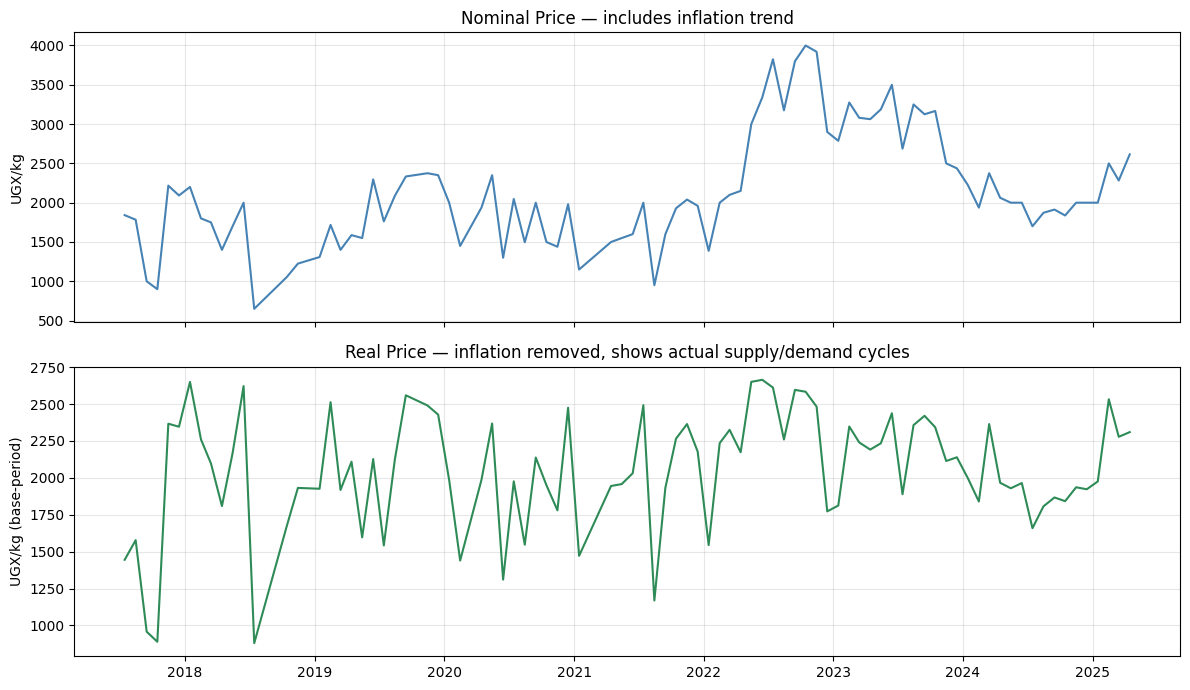

Saved → nominal_vs_real_prices.png


In [3]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(merged["date"], merged["price"], color="steelblue")
ax1.set_ylabel("UGX/kg")
ax1.set_title("Nominal Price — includes inflation trend")
ax1.grid(alpha=0.3)

ax2.plot(merged["date"], merged["real_price"], color="seagreen")
ax2.set_ylabel("UGX/kg (base-period)")
ax2.set_title("Real Price — inflation removed, shows actual supply/demand cycles")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("nominal_vs_real_prices.png", dpi=130)
plt.show()
print("Saved → nominal_vs_real_prices.png")

## 4. Build Feature Matrix (from Real Prices)

All lag features are computed from **real prices**, not nominal.
The model learns patterns in real price space — no CPI as a feature.

In [9]:
import sys
sys.path.insert(0, "../food_prices_api")
from features import compute_features

real_prices_series = merged["real_price"].tolist()
feature_rows = []
targets_real = []   # real price targets
targets_nominal = [] # nominal price targets (for MAE comparison)

for i in range(6, len(merged)):
    past_real = real_prices_series[i - 6: i]
    row = merged.iloc[i]
    feats = compute_features(past_real, int(row["month"]), int(row["year"]))
    feature_rows.append(feats)
    targets_real.append(real_prices_series[i])
    targets_nominal.append(merged["price"].iloc[i])

FEATURE_COLS = [
    "price_lag_1", "price_lag_2", "price_lag_3",
    "rolling_mean_3", "rolling_mean_6",
    "month", "year",
]

X = pd.DataFrame(feature_rows)[FEATURE_COLS]
y_real = pd.Series(targets_real)
y_nominal = pd.Series(targets_nominal)
merged_trimmed = merged.iloc[6:].reset_index(drop=True)

print(f"Feature matrix : {X.shape}")
print(f"Features       : {FEATURE_COLS}")
print(f"Note: all price values in the feature matrix are REAL (inflation-adjusted)")
X.head()

Feature matrix : (81, 7)
Features       : ['price_lag_1', 'price_lag_2', 'price_lag_3', 'rolling_mean_3', 'rolling_mean_6', 'month', 'year']
Note: all price values in the feature matrix are REAL (inflation-adjusted)


,price_lag_1,price_lag_2,price_lag_3,rolling_mean_3,rolling_mean_6,month,year
0,2346.506823,2367.067335,889.677956,1867.7507,1597.3995,1,2018
1,2650.232016,2346.506823,2367.067335,2454.6021,1798.2909,2,2018
2,2260.324030,2650.232016,2346.506823,2419.0210,1911.9808,3,2018
3,2098.356567,2260.324030,2650.232016,2336.3042,2102.0275,4,2018
4,1809.098733,2098.356567,2260.324030,2055.9264,2255.2643,5,2018


## 5. Train / Test Split

In [10]:
train_mask = merged_trimmed["year"] <= 2023
X_train, X_test = X[train_mask], X[~train_mask]
y_real_train, y_real_test = y_real[train_mask], y_real[~train_mask]
y_nom_test = y_nominal[~train_mask]
cpi_test = merged_trimmed[~train_mask]["maize_cpi"].values

print(f"Train : {len(X_train)} rows  ({merged_trimmed[train_mask]['date'].min().date()} to {merged_trimmed[train_mask]['date'].max().date()})")
print(f"Test  : {len(X_test)} rows  ({merged_trimmed[~train_mask]['date'].min().date()} to {merged_trimmed[~train_mask]['date'].max().date()})")

Train : 65 rows  (2018-01-15 to 2023-12-15)
Test  : 16 rows  (2024-01-15 to 2025-04-15)


## 6. Train and Evaluate

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_real_train)

# Predict in real price space
y_real_pred = model.predict(X_test)

# Re-inflate to nominal for comparison with other models
y_nominal_pred = y_real_pred * cpi_test / 100

mae_real    = mean_absolute_error(y_real_test, y_real_pred)
mae_nominal = mean_absolute_error(y_nom_test, y_nominal_pred)

print(f"MAE (real prices)    : {mae_real:,.0f} base-period UGX/kg")
print(f"MAE (re-inflated)    : {mae_nominal:,.0f} UGX/kg  ← compare to other models")
print()
print("Comparison (all in nominal UGX/kg):")
print(f"  Naive baseline (rolling mean 3) : 196")
print(f"  v3 — CPI as feature (65 rows)   : 224")
print(f"  v4 — FX + global maize (155 rows): 223")
print(f"  v5 — real prices, no CPI feature : {mae_nominal:,.0f}  ← this model")

MAE (real prices)    : 256 base-period UGX/kg
MAE (re-inflated)    : 263 UGX/kg  ← compare to other models

Comparison (all in nominal UGX/kg):
  Naive baseline (rolling mean 3) : 196
  v3 — CPI as feature (65 rows)   : 224
  v4 — FX + global maize (155 rows): 223
  v5 — real prices, no CPI feature : 263  ← this model


## 7. Feature Importance

In [11]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("Feature importances (no CPI — how does each feature rank now?):")
for name, score in importances.items():
    bar = "█" * int(score * 40)
    print(f"  {score:.4f}  {bar}  {name}")

print()
print("v3 importances for comparison:")
print("  0.5880  ████████████████████████  food_cpi  ← this is gone")
print("  0.1233  █████                     price_lag_1")

Feature importances (no CPI — how does each feature rank now?):
  0.2429  █████████  price_lag_1
  0.1917  ███████  rolling_mean_6
  0.1261  █████  price_lag_3
  0.1242  ████  rolling_mean_3
  0.1196  ████  month
  0.1155  ████  year
  0.0800  ███  price_lag_2

v3 importances for comparison:
  0.5880  ████████████████████████  food_cpi  ← this is gone
  0.1233  █████                     price_lag_1


## 8. Save Model

In [12]:
import joblib

joblib.dump(model, "maize_price_model_v5.pkl")
print("Saved → maize_price_model_v5.pkl")
print()
print("IMPORTANT — API changes needed to deploy v5:")
print("  1. Lag features must be computed from REAL prices, not nominal")
print("  2. User still provides last 6 nominal prices")
print("  3. API deflates them using current CPI before computing features")
print("  4. Model predicts real price")
print("  5. API re-inflates: nominal = real_pred * current_cpi / 100")

Saved → maize_price_model_v5.pkl

IMPORTANT — API changes needed to deploy v5:
  1. Lag features must be computed from REAL prices, not nominal
  2. User still provides last 6 nominal prices
  3. API deflates them using current CPI before computing features
  4. Model predicts real price
  5. API re-inflates: nominal = real_pred * current_cpi / 100
